In [1]:
# Whether regulatory authorities publish published reports on water quality/drinking water delivery
# https://glaas.who.int/glaas/data?aW5kPVJFR0FfUkVQVFdRJTJDUkVHQV9SRVBUREVMSVYmdGltZT0yMDIxJmFwcGx5PXRydWU=

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_excel("../data/glaas.xlsx", sheet_name="Raw data")

# Just to be sure - check columns
print(df.columns)

Index(['Ind', 'Indicator', 'ISO3', 'Countries, territories and areas', 'Year',
       'Service_code', 'Service', 'Setting_code', 'Setting', 'Value (text)',
       'Value (numerical)', 'Unit of measure'],
      dtype='object')


c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


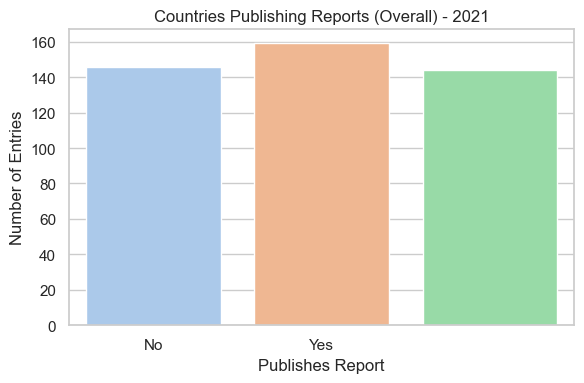

In [2]:
# Global Bar Chart: Publish vs Not Publish

# Count how many 1s (Yes) and 0s (No)
report_counts = df['Value (numerical)'].value_counts()

# Plot
# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(6,4))
sns.barplot(x=report_counts.index, y=report_counts.values, palette="pastel")
plt.xticks([0,1], ['No', 'Yes'])
plt.title("Countries Publishing Reports (Overall) - 2021")
plt.ylabel("Number of Entries")
plt.xlabel("Publishes Report")
plt.tight_layout()
plt.show()

c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\celia\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is depr

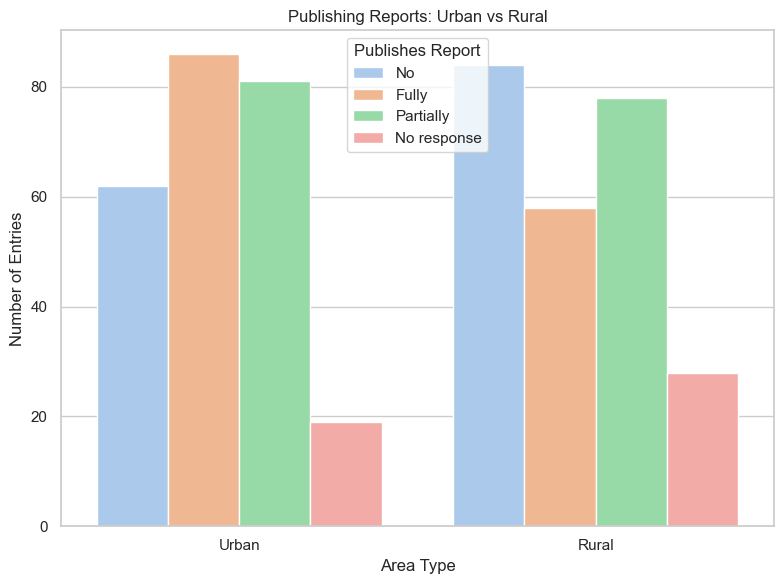

In [3]:
# Filter only Urban, Rural, National settings
filtered_df = df[df['Setting'].isin(['Urban', 'Rural', 'National'])]

# Now plot
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.countplot(data=filtered_df, x='Setting', hue='Value (text)', palette="pastel")
plt.title("Publishing Reports: Urban vs Rural")
plt.xlabel("Area Type")
plt.ylabel("Number of Entries")
plt.legend(title="Publishes Report", loc="upper center")
plt.tight_layout()
plt.show()


In [4]:
import plotly.express as px

fig = px.histogram(filtered_df, x='Setting', color='Value (text)', barmode='group',
                   title="Publishing Reports: Urban vs Rural", color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(height=500)

fig.write_html("../visualizations/publishing_bar_chart.html")


In [5]:
import plotly.express as px

# Strip any whitespace in column names just in case
df.columns = df.columns.str.strip()

# Filter only Urban, Rural, National settings
filtered_df = df[df['Setting'].isin(['Urban', 'Rural', 'National'])]

# Create interactive grouped bar chart
fig = px.histogram(
    filtered_df,
    x='Setting',
    color='Value (text)',
    barmode='group',
    title='Publishing Reports: Urban vs Rural',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Customize layout
fig.update_layout(
    xaxis_title='Area Type',
    yaxis_title='Number of Entries',
    legend_title='Publishes Report',
    template='plotly_white'
)

# Save to HTML
fig.write_html("../visualizations/urban_rural_publishing_bar.html")



In [6]:
# Install plotly

!pip install plotly


    extract-msg (<=0.29.*)
                 ~~~~~~~^


In [7]:
import plotly.express as px

# Average publishing value per country
country_status = df.groupby('Countries, territories and areas')['Value (numerical)'].mean().reset_index()

# Plot
fig = px.choropleth(country_status,
                    locations="Countries, territories and areas",
                    locationmode="country names",
                    color="Value (numerical)",
                    color_continuous_scale=["red", "green"],
                    title="Global Transparency in Water Reporting")

fig.update_geos(
    projection_type="natural earth",
    showcoastlines=True,
    showland=True,
    landcolor="LightGray"
)

fig.show()
fig.write_html("../visualizations/transparency_map.html", include_plotlyjs='cdn')


In [8]:
# kip first 4 junk rows
df = pd.read_excel('../data/glaas.xlsx', skiprows=4)

# remove spaces 
df.columns = df.columns.str.strip()

# Check columns
print(df.columns.tolist())

['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Urban', 'Rural', 'Urban.1', 'Rural.1']


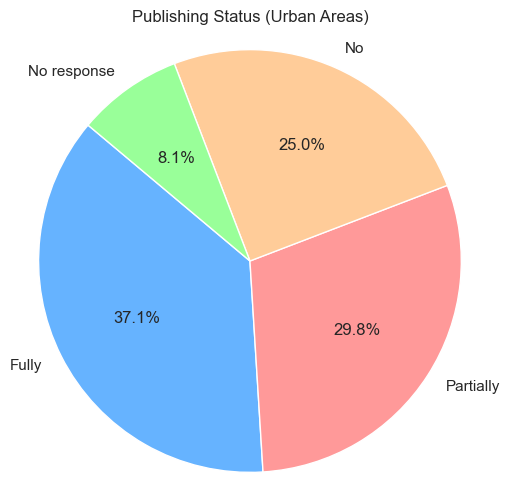

In [9]:
# Use the first 'Urban' column
publish_counts = df['Urban'].value_counts()

# labels and sizes
labels = publish_counts.index.tolist()
sizes = publish_counts.values.tolist()

# colors
colors = ['#66b3ff', '#ff9999', '#ffcc99', '#99ff99']

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.axis('equal')
plt.title('Publishing Status (Urban Areas)')
plt.show()


In [10]:

# write the file
fig.write_html("../visualizations/urban_publishing_pie.html")


In [11]:
import plotly.graph_objects as go
import pandas as pd

# Assuming df['Urban'] exists
publish_counts = df['Urban'].value_counts()
labels = publish_counts.index.tolist()
sizes = publish_counts.values.tolist()

# Create Plotly Pie Chart
fig = go.Figure(data=[go.Pie(
    labels=labels,
    values=sizes,
    hole=0.3,  # optional, makes it a donut chart
    marker=dict(colors=['#66b3ff', '#ff9999', '#ffcc99', '#99ff99'])
)])

fig.update_layout(
    title_text='Publishing Status (Urban Areas)',
)

# Save to HTML
fig.write_html("../visualizations/urban_publishing_pie.html")


In [12]:
print(df.columns.tolist())


['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Urban', 'Rural', 'Urban.1', 'Rural.1']


In [15]:
import os
os.makedirs("../data/data_froggy", exist_ok=True)

In [16]:
# clean csv for froggy

import pandas as pd

# Rename columns for clarity
df.columns = df.columns.str.strip()
df.columns = ['ISO3', 'Country', 'Year', 'Urban_ATH09', 'Rural_ATH09', 'Urban_ATH10', 'Rural_ATH10']

# Reshape to long format
df_long = df.melt(
    id_vars=['ISO3', 'Country'],
    value_vars=['Urban_ATH09', 'Rural_ATH09', 'Urban_ATH10', 'Rural_ATH10'],
    var_name='Setting_Indicator',
    value_name='Value Text'
)

# Parse Area and Indicator
df_long['Area'] = df_long['Setting_Indicator'].apply(lambda x: 'Urban' if 'Urban' in x else 'Rural')
df_long['Indicator'] = df_long['Setting_Indicator'].apply(lambda x: 'ATH09' if 'ATH09' in x else 'ATH10')

# Drop blanks
df_long = df_long.dropna()
df_long = df_long[df_long['Value Text'].astype(str).str.strip() != '']

# Add count summary for share (%)
group_counts = (
    df_long.groupby(['Area', 'Value Text'])
    .size()
    .reset_index(name='Count')
)

group_counts['Share (%)'] = (
    group_counts.groupby('Area')['Count']
    .transform(lambda x: round(100 * x / x.sum(), 1))
)

#  Merge summary back into full df for unified CSV
df_combined = df_long.merge(
    group_counts,
    on=['Area', 'Value Text'],
    how='left'
)

# Final column order
df_combined = df_combined[['ISO3', 'Country', 'Area', 'Indicator', 'Value Text', 'Count', 'Share (%)']]

# Save to a single CSV
df_combined.to_csv("../data/data_froggy/data_reporting_transparency_combined.csv", index=False)
print("CSV saved: data_froggy/data_reporting_transparency_combined.csv")



CSV saved: data_froggy/data_reporting_transparency_combined.csv
